```{index} Statically indeterminate structures; Exam assignment
```
```{index} Continuum mechanics; Exam assignment
```
```{index} Buckling; Exam assignment
```

(exam4)=
# Exam Monday April 14th

Today you'll make the third exam assignment covering Statically indeterminate structures including its prerequisites and/or the third exam assignment covering Continuum mehcanics including its prerequisites and/or the second exam assignment covering Buckling including its prerequisites. For more information about the exam see [the assessment information in course information](exam-general)

## Exam assignment 3 Statically indeterminate structures
Your own submission and its grading will be available here after the exam.


In [43]:
import sympy as sym
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_formats = ['svg']

L1, L2, L3, F, EI, EA = sym.symbols('L1 L2 L3 F EI EA', real=True, positive=True)

L1 = 4
L2 = 4
L3 = 2
F = 150
EI = sym.nsimplify(2500)
EA = sym.nsimplify(20)

Av, Ah = sym.symbols('Av Ah', real=True)

w_A = F * L3 * L2 **2 / EI / 2 / 2 + F * L3 * L2 / EI / 2 * L1 \
    - Av * (L2)**3 / EI / 2 / 3 - Av * L1 * L2**2 / EI / 2 / 2 \
    - L1 * ( Av * L2**2 / EI / 2 / 2 + Av * L1 * L2 / EI / 2) \
    - Av * L1 **3 / EI / 3
u_A = F * L2 / EA / 2 - Ah * L1 / EA - Ah * L2 / EA / 2

sol = sym.solve([sym.Eq(w_A, 0), sym.Eq(u_A, 0)], (Av, Ah))
display(sol[Ah], sol[Av])


50

75/2

## Exam assignment 3 Continuum mechanics
Your own submission and its grading will be available here after the exam.

108.000000000000

10800

100

108043200

25/2501

...

0.0128038850912854

143.130102354156

-0.00348982084935980

0.0102166718562116

TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

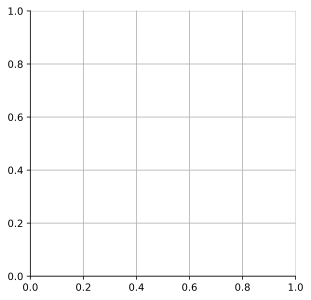

In [ ]:
import sympy as sym
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_formats = ['svg']

t, h, q, N, L, b, h_A = sym.symbols('t h q N L b h_A',real=True, positive=True)	

h = sym.nsimplify(300)
b = sym.nsimplify(300)
t = sym.nsimplify(12)
L = 6
q = sym.nsimplify(24)
#h_A = sym.nsimplify(50)

M =  q * L**2 / 8
V = q * L / 2

N = V / 4 * 3
display(M.evalf())
tau = 0
A = b*t+h*t*2
display(A)
zc = h*t*2*h/2 / A
display(zc)
Izz = b * t**3 / 12 + b * t * zc**2 + 2 * t * h**3 / 12 + 2 * t * h * (zc - h/2)**2
display(Izz)
S_a = h * t * (h/2 - zc)
tau = V * (S_a) / t / Izz
sigma = N / A
display(tau)
display(tau.evalf())
display(sigma)
display(sigma.evalf())

sigma_min = (sigma)/2-sym.sqrt(((-sigma)/2)**2+tau**2)
sigma_max = (sigma)/2+sym.sqrt(((-sigma)/2)**2+tau**2)
display(sigma_min.evalf())
display(sigma_max.evalf())
#alpha_0 = sym.atan2(-tau,-sigma/2)/2
#display((alpha_0*180/sym.pi).evalf())
#print(np.rad2deg(alpha_tau))

#f_y = sym.sqrt(((sigma_max - sigma_min)**2 + sigma_max **2 + sigma_min**2)/2)
#display(f_y)
#f_y_2 = sym.sqrt(sigma**2 + 3 * tau**2)
#display(f_y_2)
#display(f_y_2.evalf())

#alpha = sym.pi  / 4
alpha = sym.atan2(3, -4)/sym.pi*180
display(alpha.evalf())
sigma_xx = sigma * sym.cos(alpha)**2 + 2 * tau * sym.sin(alpha) * sym.cos(alpha)
tau_xy = - sigma * sym.sin(alpha) * sym.cos(alpha) + tau * (sym.sin(alpha)**2 - sym.cos(alpha)**2)
display(sigma_xx.evalf())
display(tau_xy.evalf())
#tau_xy = - sigma*sym.sin(alpha)*sym.cos(alpha)
#display(sigma_xx)
#display(tau_xy)


plt.figure()
ax = plt.gca()
ax.set_aspect('equal')
ax.spines['right'].set_color('none')
ax.spines['bottom'].set_position('zero')
ax.spines['left'].set_position('zero')
ax.spines['top'].set_color('none')
plt.grid()
if sigma_min<0:
    plt.xlim([1.1*sigma_min,1.4*sigma_max])
else:
    plt.xlim([0.7*sigma_min,1.1*sigma_max])
#plt.ylim([-1.1*tau_max,1.1*tau_max])
plt.xlabel('xx, yy')
ax.xaxis.set_label_coords(0.95, 0.55)
ax.yaxis.set_label_coords(0,0.95)
#plt.ylabel(r'$\tau$')
plt.plot(sigma,-tau,marker='o')
plt.plot(sigma,tau,marker='o')
#plt.show()
plt.plot([sigma_x,sigma_y],[-tau,tau])
plt.plot((sigma_x+sigma_y)/2,0,marker='o')
circle1 = plt.Circle([(sigma_x+sigma_y)/2,0],np.sqrt(((sigma_x-sigma_y)/2)**2+tau**2),fill=False)
ax.add_artist(circle1)
plt.plot(sigma_max,0,marker='o')
plt.plot(sigma_min,0,marker='o')
#plt.show()
plt.plot([sigma_y,sigma_x],[-tau,-tau],color='black')
plt.plot([sigma_y,sigma_y],[-tau,tau],color='black')
plt.plot(sigma_y,-tau,marker='o',color='black')
plt.plot([sigma_y,sigma_max],[-tau,0],color='black')


# Add curved arrow from sigma_y/2, -tau to the last line shown
arrow = patches.FancyArrowPatch((sigma_x/2, -tau), (sigma_x/2*np.cos(alpha), -tau+np.sin(alpha)*sigma_x/2), connectionstyle="arc3,rad=.3", color="black", arrowstyle='simple',mutation_scale=15)
ax.add_patch(arrow)



s_v = np.sqrt(sigma_min**2-sigma_min*sigma_max+sigma_max**2)
print('vloeispanning =',s_v)
#plt.show()


plt.gcf().patch.set_alpha(0)

# Save the figure with transparent background
#plt.savefig('plot.svg', format='svg', transparent=True);

## Exam assignment 2 Buckling
Your own submission and its grading will be available here after the exam.